In [1]:
# importing libraries
import pandas as pd#
import seaborn as sns# 
import numpy as np #
from scipy import stats#
from scipy.stats import ttest_ind #
from scipy.stats import f_oneway#
from sklearn.linear_model import LinearRegression#
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix #

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
le = LabelEncoder()
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt#
from sklearn.model_selection import train_test_split
from matplotlib import pyplot
from sklearn.model_selection import cross_val_score
from scipy.stats import chi2_contingency
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import StratifiedKFold

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis #
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

from scipy import stats

import statsmodels.api as sm
from statsmodels.formula.api import ols #ordinary least square 
import statsmodels.stats.api as sms
from sklearn.preprocessing import StandardScaler

In [2]:
#pip install pandas openpyxl
#%pip install statsmodels

In [3]:
df = pd.read_excel('df.xlsx')

In [4]:
#data prep 1

In [5]:
df.head()

,county,avg_income_eur,avg_land_price_eur_m2,transport_score,school_quality_index,crime_rate_per_10k,green_space_pct,flood_risk_score,broadband_score,house_type,demand_score,demand_category,predicted_house_price_eur
0,Carlow,35980.28,75.85,5.97,7.02,27.66,28.13,3.18,5.44,Apartment,64.448103,Average,78098.14
1,Carlow,29571.72,52.28,1.08,6.45,38.16,17.81,1.68,5.24,Semi-Detached,36.735072,Average,73503.34
2,Carlow,29733.70,83.33,3.27,5.88,23.99,27.67,0.67,6.99,Terraced,36.575152,Average,75004.94
3,Carlow,49669.88,115.81,5.33,6.38,19.91,17.33,3.15,4.64,Detached,65.913075,Average,152940.93
4,Carlow,28938.47,98.35,6.55,6.43,21.61,27.53,1.66,4.67,Detached,44.816833,Average,107326.78


In [6]:
df.shape

(2080, 13)

In [7]:
df.describe()

,avg_income_eur,avg_land_price_eur_m2,transport_score,school_quality_index,crime_rate_per_10k,green_space_pct,flood_risk_score,broadband_score,demand_score,predicted_house_price_eur
count,2077.000000,2080.000000,2077.000000,2075.000000,2075.000000,2080.000000,2077.000000,2080.000000,2080.000000,2080.000000
mean,33221.662090,87.895942,5.110558,5.560255,30.752882,29.394457,2.992210,6.032928,50.812593,97816.662375
std,6098.363519,50.865574,1.583743,0.991515,10.279688,8.379302,2.309292,1.213262,15.023287,51423.537127
min,20000.000000,10.000000,1.000000,2.180000,5.000000,0.000000,0.030000,2.140000,0.000000,45000.000000
25%,29029.280000,59.927500,4.060000,4.890000,23.475000,23.965000,1.270000,5.210000,40.550864,72847.927500
50%,33091.360000,81.210000,5.100000,5.580000,30.600000,29.675000,2.240000,6.060000,50.585581,87998.230000
75%,37364.120000,103.265000,6.160000,6.260000,37.470000,35.065000,3.930000,6.840000,61.132100,106682.270000
max,55124.800000,390.440000,10.000000,9.010000,73.920000,58.890000,10.000000,10.000000,100.000000,488286.860000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2080 entries, 0 to 2079
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   county                     2080 non-null   object 
 1   avg_income_eur             2077 non-null   float64
 2   avg_land_price_eur_m2      2080 non-null   float64
 3   transport_score            2077 non-null   float64
 4   school_quality_index       2075 non-null   float64
 5   crime_rate_per_10k         2075 non-null   float64
 6   green_space_pct            2080 non-null   float64
 7   flood_risk_score           2077 non-null   float64
 8   broadband_score            2080 non-null   float64
 9   house_type                 2080 non-null   object 
 10  demand_score               2080 non-null   float64
 11  demand_category            2080 non-null   object 
 12  predicted_house_price_eur  2080 non-null   float64
dtypes: float64(10), object(3)
memory usage: 211.4+ K

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns

Index(['county', 'avg_income_eur', 'avg_land_price_eur_m2', 'transport_score',
       'school_quality_index', 'crime_rate_per_10k', 'green_space_pct',
       'flood_risk_score', 'broadband_score', 'house_type', 'demand_score',
       'demand_category', 'predicted_house_price_eur'],
      dtype='object')

In [11]:
#data prep 2

In [12]:
df = df.rename(columns={'avg_income_eur':'income','avg_land_price_eur_m2':'land_price'})

In [13]:
df.columns

Index(['county', 'income', 'land_price', 'transport_score',
       'school_quality_index', 'crime_rate_per_10k', 'green_space_pct',
       'flood_risk_score', 'broadband_score', 'house_type', 'demand_score',
       'demand_category', 'predicted_house_price_eur'],
      dtype='object')

In [14]:
#Exploring each column to check its data type, number of unique values and distribution of values
columns = ['county', 'income', 'land_price', 'transport_score',
       'school_quality_index', 'crime_rate_per_10k', 'green_space_pct',
       'flood_risk_score', 'broadband_score', 'house_type', 'demand_score',
       'demand_category', 'predicted_house_price_eur']

for col in columns:
    print(col)
    print('Data Type:' ,df[col].dtype)
    print(df[col].nunique())
    print(df[col].value_counts())
    print('___________________________________________')

county
Data Type: object
26
county
Carlow       80
Cavan        80
Clare        80
Cork         80
Donegal      80
Dublin       80
Galway       80
Kerry        80
Kildare      80
Kilkenny     80
Laois        80
Leitrim      80
Limerick     80
Longford     80
Louth        80
Mayo         80
Meath        80
Monaghan     80
Offaly       80
Roscommon    80
Sligo        80
Tipperary    80
Waterford    80
Westmeath    80
Wexford      80
Wicklow      80
Name: count, dtype: int64
___________________________________________
income
Data Type: float64
2046
income
20000.00    31
33921.29     2
29571.72     1
29733.70     1
49669.88     1
            ..
35653.61     1
27526.55     1
37551.88     1
30774.83     1
38681.16     1
Name: count, Length: 2046, dtype: int64
___________________________________________
land_price
Data Type: float64
1900
land_price
10.00     11
94.75      4
88.90      4
104.27     3
78.33      3
          ..
77.34      1
91.05      1
97.73      1
92.72      1
93.24      1
Nam

In [15]:
df = df.replace('Unknown', np.nan) 

In [16]:
# calculating the percentage of missing values in each column
(df.isnull().sum()*100/4600).round(2)

county                       0.00
income                       0.07
land_price                   0.00
transport_score              0.07
school_quality_index         0.11
crime_rate_per_10k           0.11
green_space_pct              0.00
flood_risk_score             0.07
broadband_score              0.00
house_type                   0.20
demand_score                 0.00
demand_category              0.00
predicted_house_price_eur    0.00
dtype: float64

In [17]:
# dropping observations with missing data
dfclean=df.dropna(axis=0,how="any")

In [18]:
dfclean.shape

(2053, 13)

In [19]:
dfclean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2053 entries, 0 to 2079
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   county                     2053 non-null   object 
 1   income                     2053 non-null   float64
 2   land_price                 2053 non-null   float64
 3   transport_score            2053 non-null   float64
 4   school_quality_index       2053 non-null   float64
 5   crime_rate_per_10k         2053 non-null   float64
 6   green_space_pct            2053 non-null   float64
 7   flood_risk_score           2053 non-null   float64
 8   broadband_score            2053 non-null   float64
 9   house_type                 2053 non-null   object 
 10  demand_score               2053 non-null   float64
 11  demand_category            2053 non-null   object 
 12  predicted_house_price_eur  2053 non-null   float64
dtypes: float64(10), object(3)
memory usage: 224.5+ KB


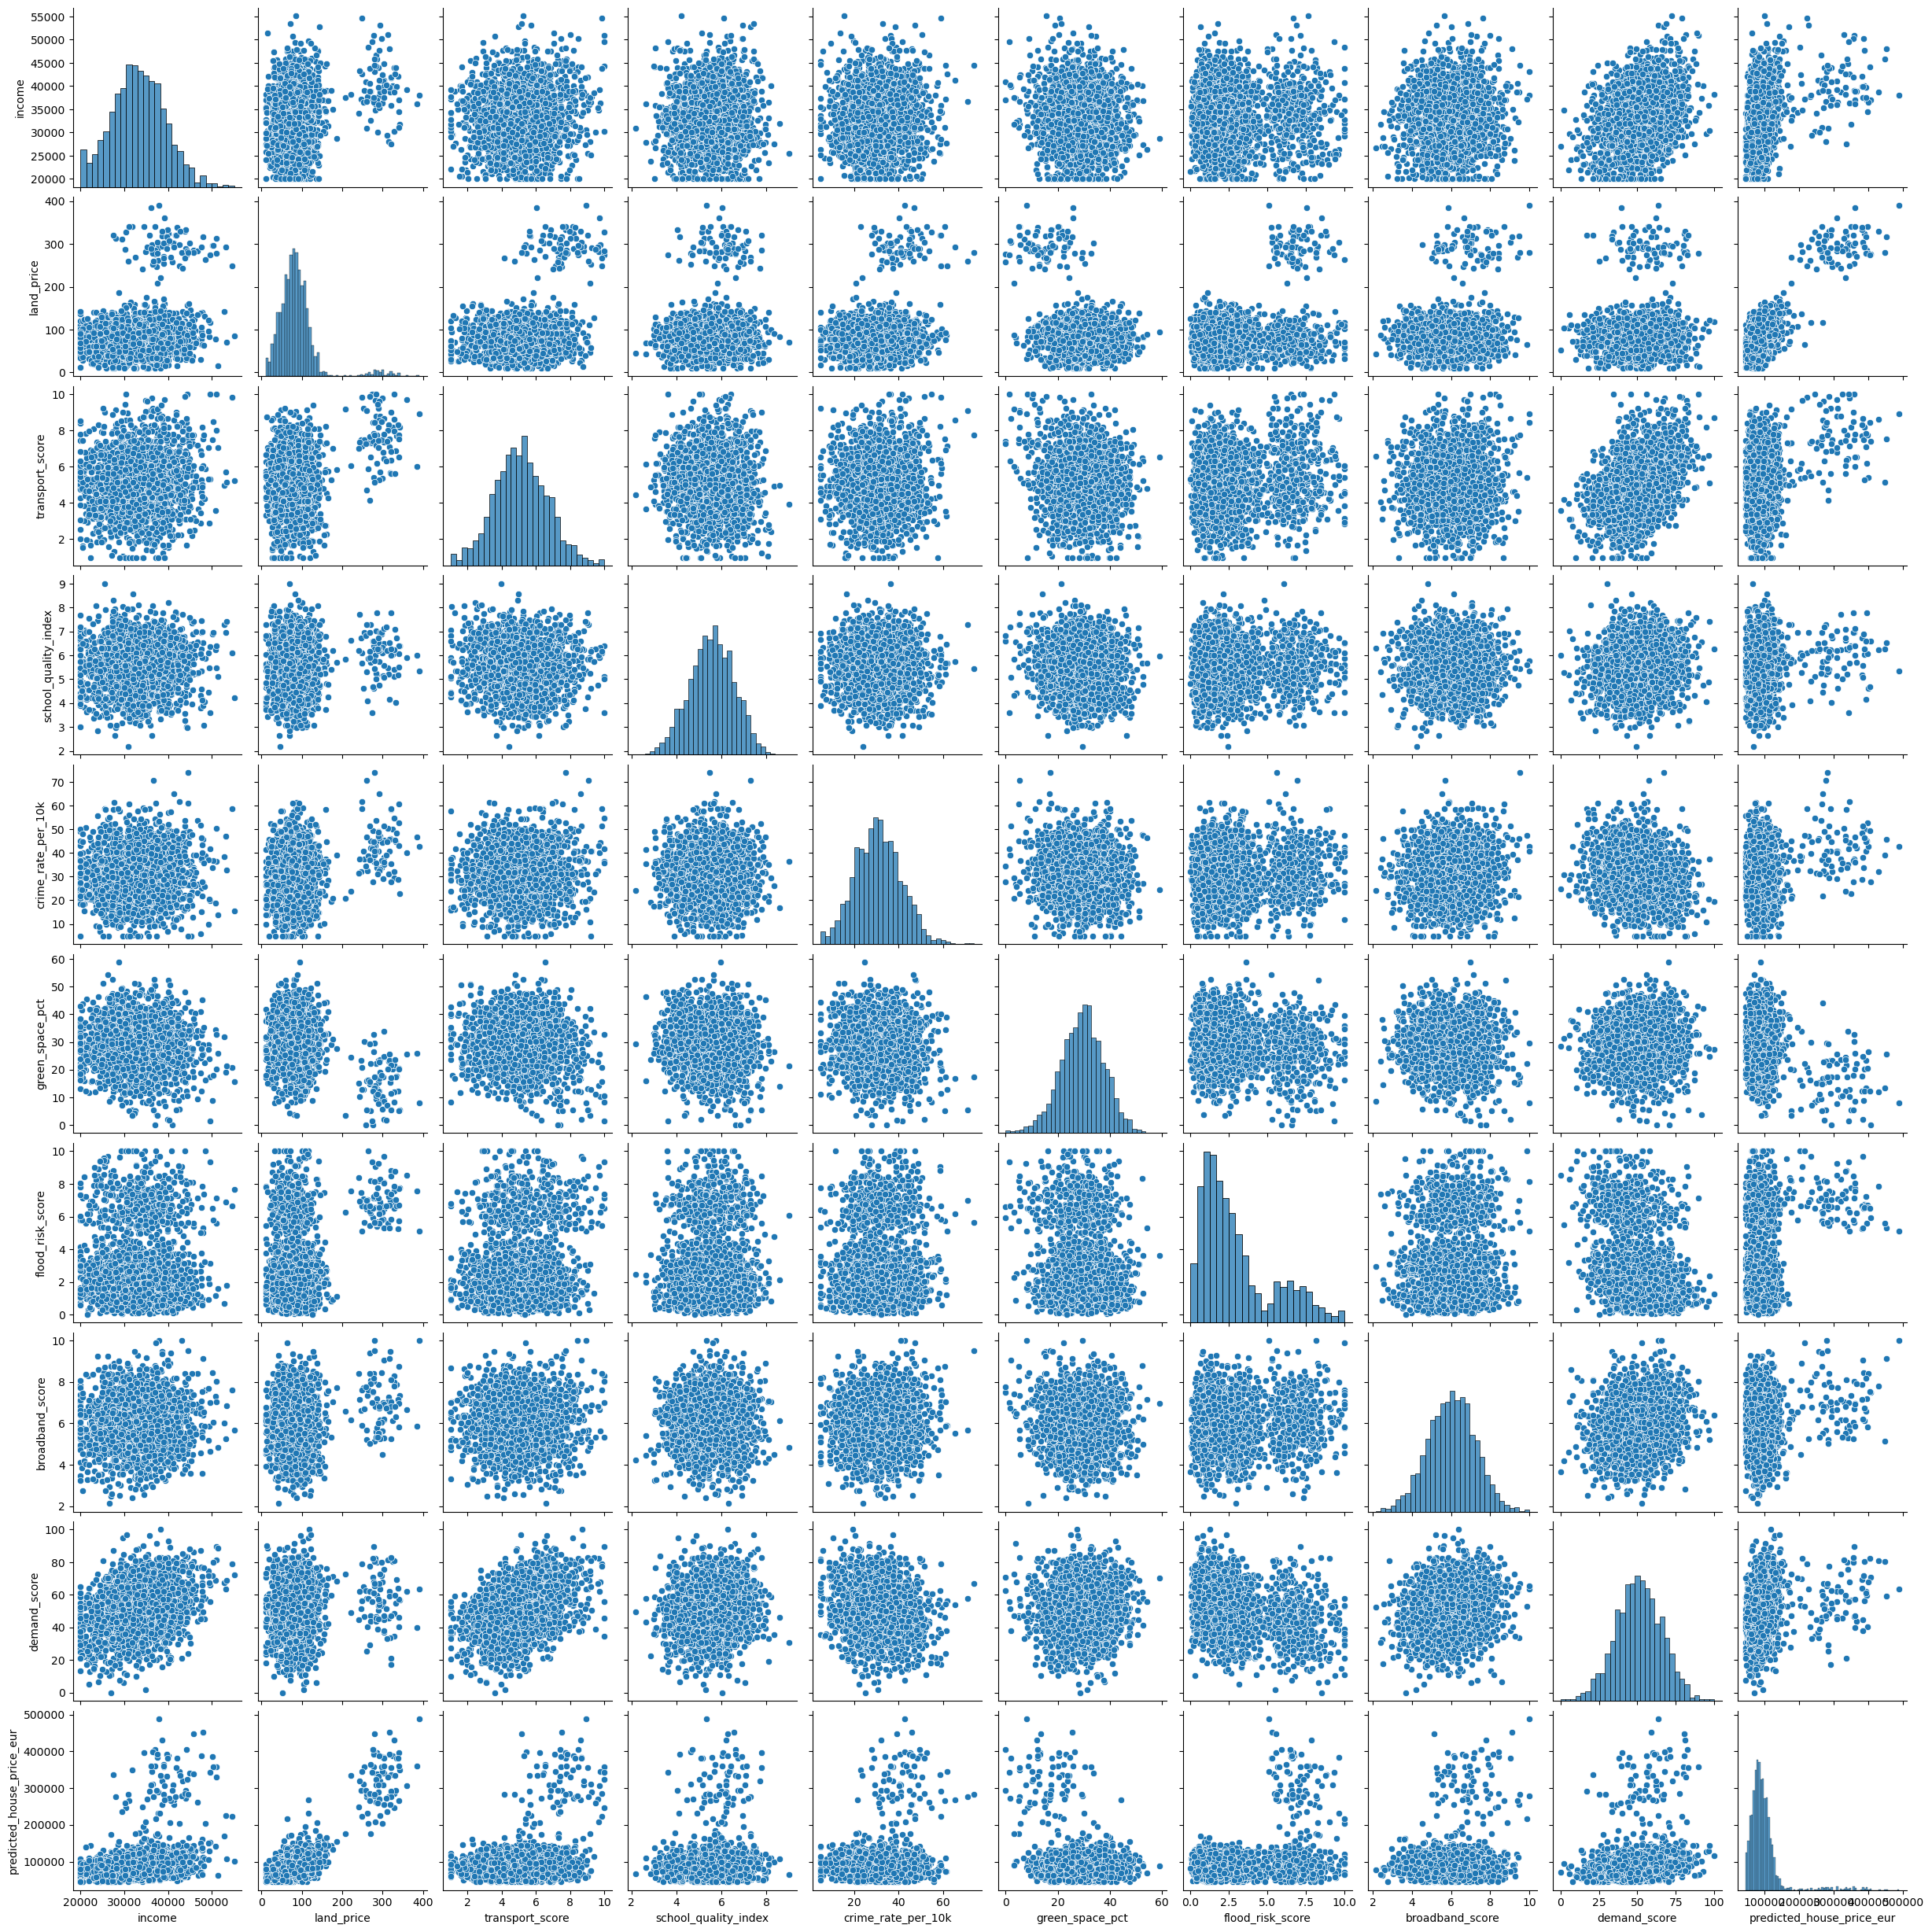

In [20]:
# creating a pairplot with all the numeric columns
sns.pairplot(dfclean)

county
Max value Wicklow


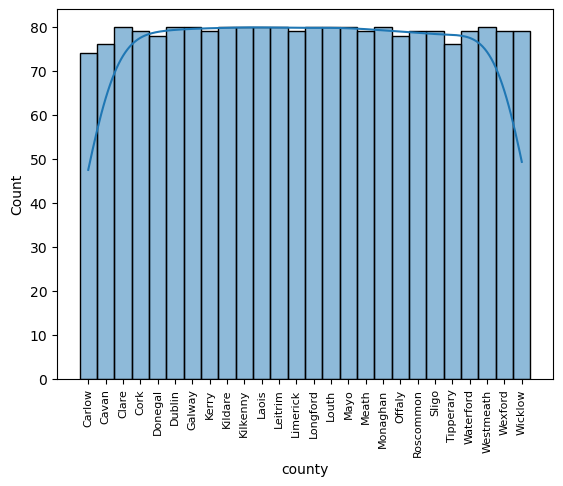

income
Max value 55124.8


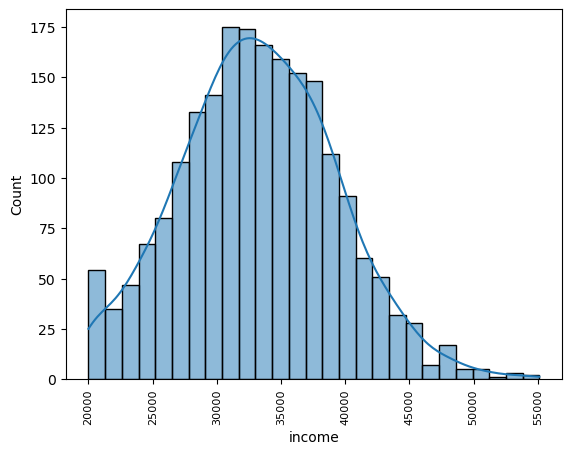

land_price
Max value 390.44


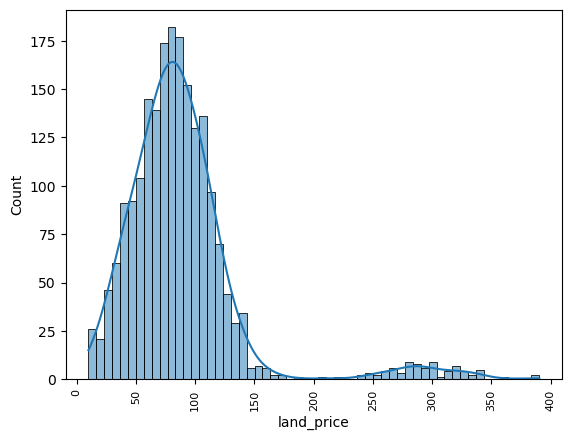

transport_score
Max value 10.0


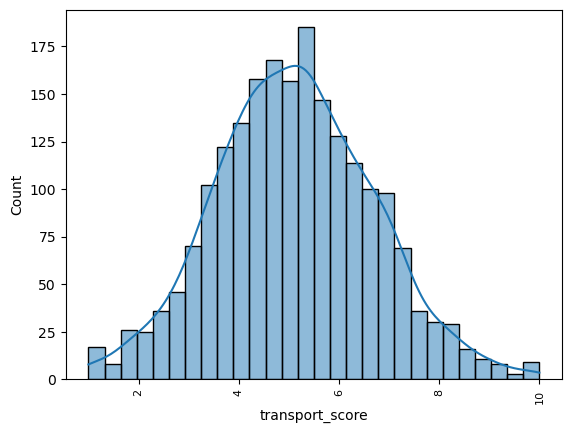

school_quality_index
Max value 9.01


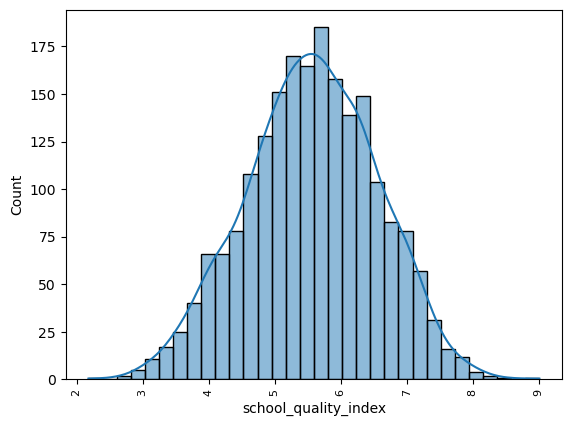

crime_rate_per_10k
Max value 73.92


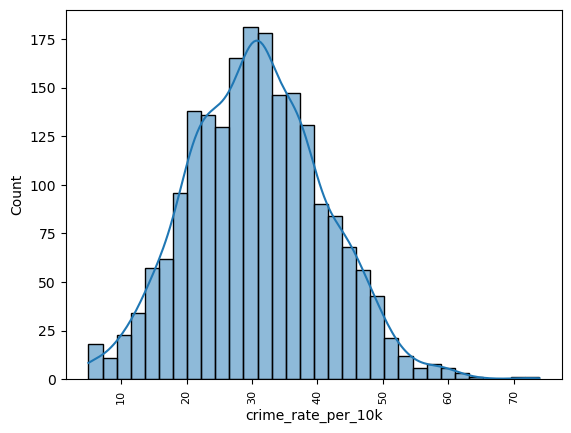

green_space_pct
Max value 58.89


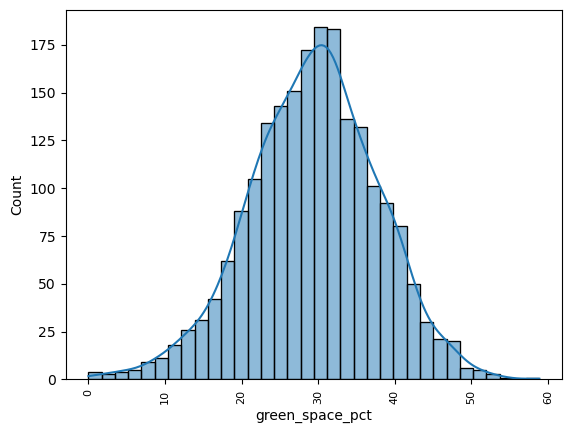

flood_risk_score
Max value 10.0


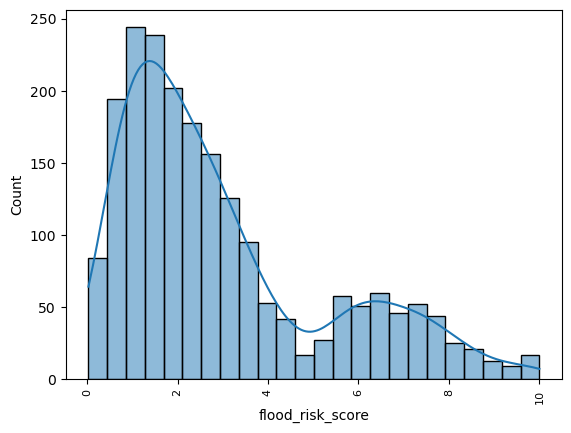

broadband_score
Max value 10.0


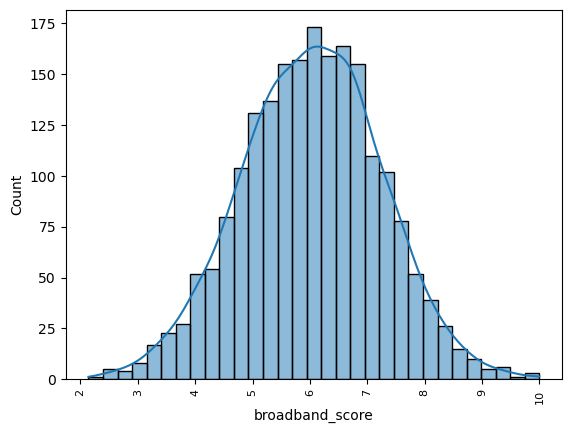

house_type
Max value Terraced


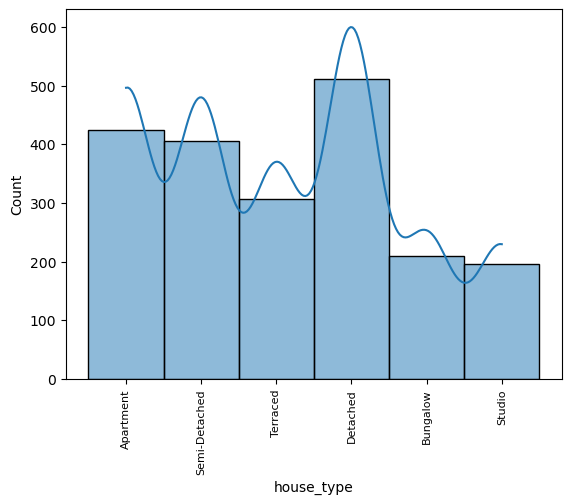

demand_score
Max value 100.0


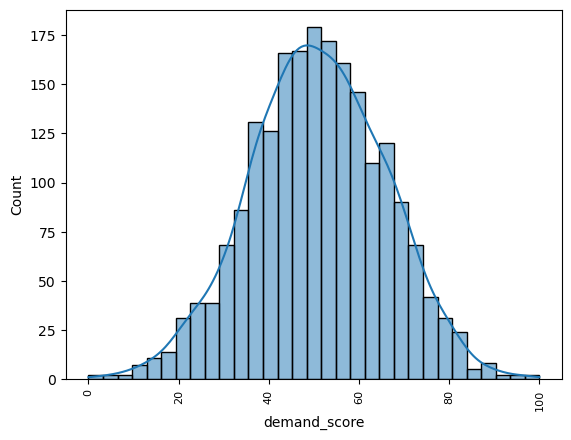

demand_category
Max value Low


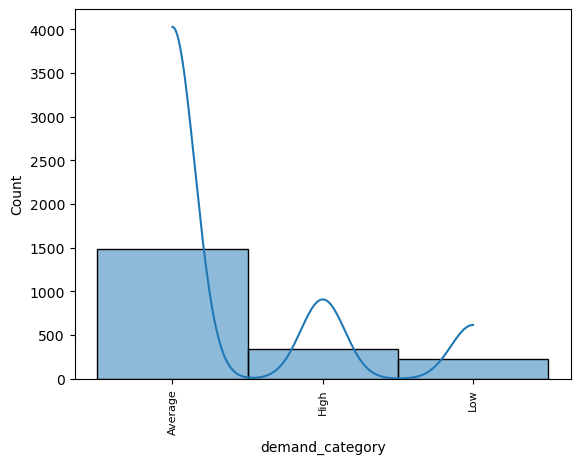

predicted_house_price_eur
Max value 488286.86


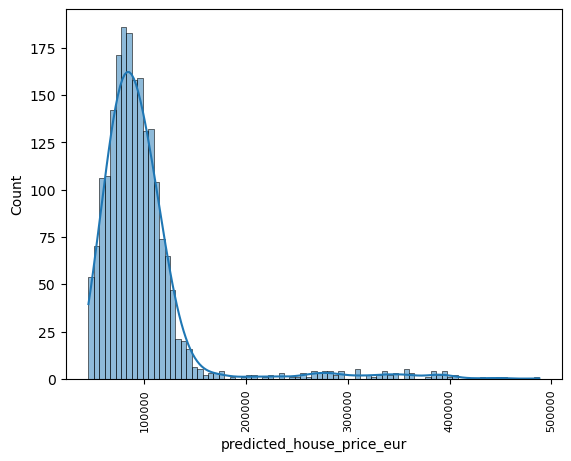

In [21]:
# creating histplots with features
columns = ['county', 'income', 'land_price', 'transport_score',
       'school_quality_index', 'crime_rate_per_10k', 'green_space_pct',
       'flood_risk_score', 'broadband_score', 'house_type', 'demand_score',
       'demand_category', 'predicted_house_price_eur']

for col in columns:
    print(col)
    data = dfclean[col]
    print("Max value", data.max())
    sns.histplot(data, kde=True)
    plt.xticks(rotation=90, fontsize=8)
    plt.show()

county
Max value Wicklow


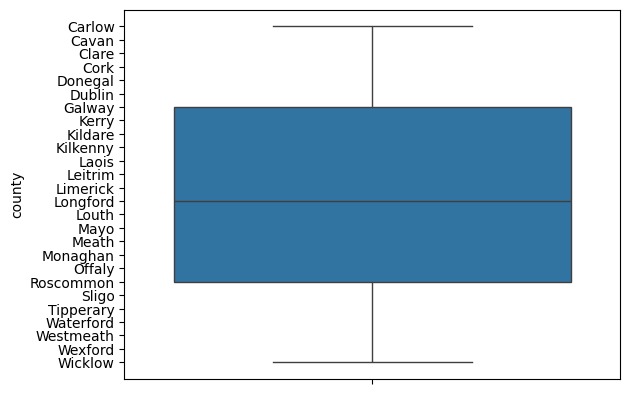

income
Max value 55124.8


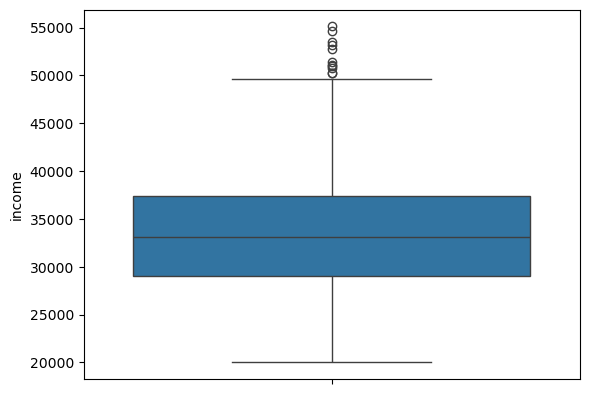

land_price
Max value 390.44


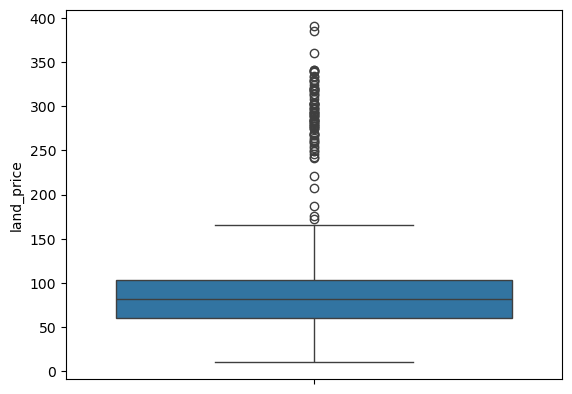

transport_score
Max value 10.0


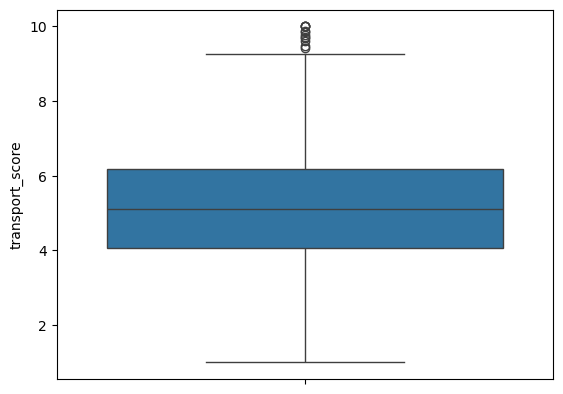

school_quality_index
Max value 9.01


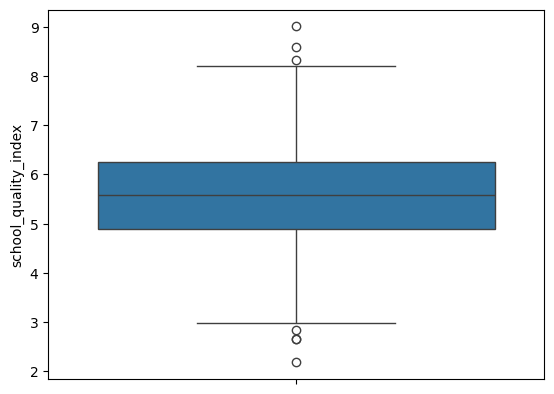

crime_rate_per_10k
Max value 73.92


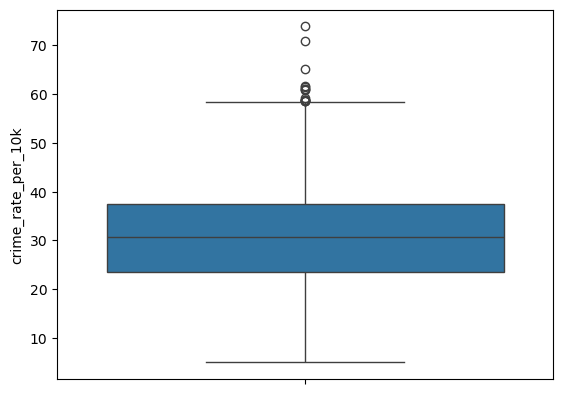

green_space_pct
Max value 58.89


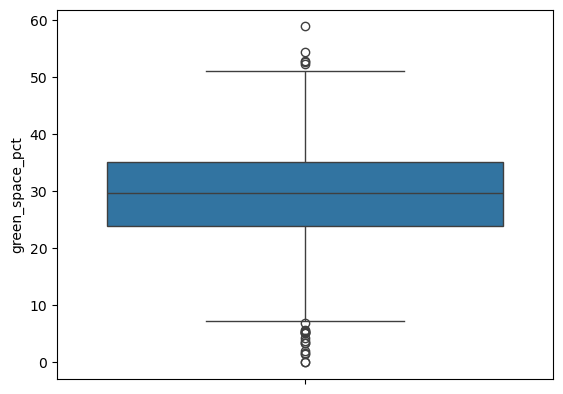

flood_risk_score
Max value 10.0


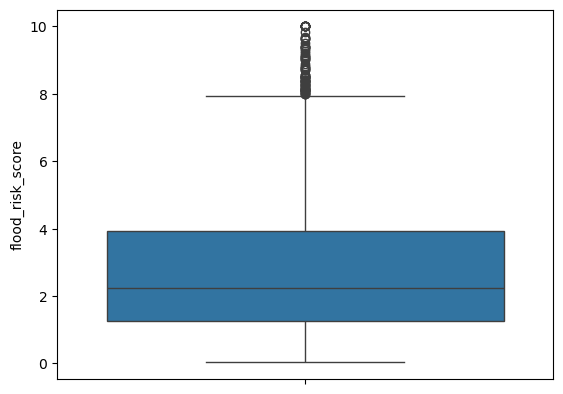

broadband_score
Max value 10.0


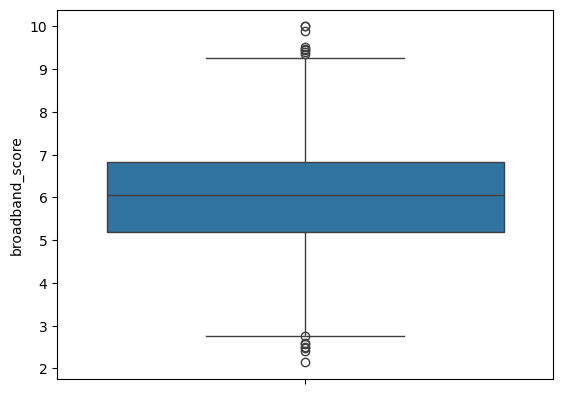

house_type
Max value Terraced


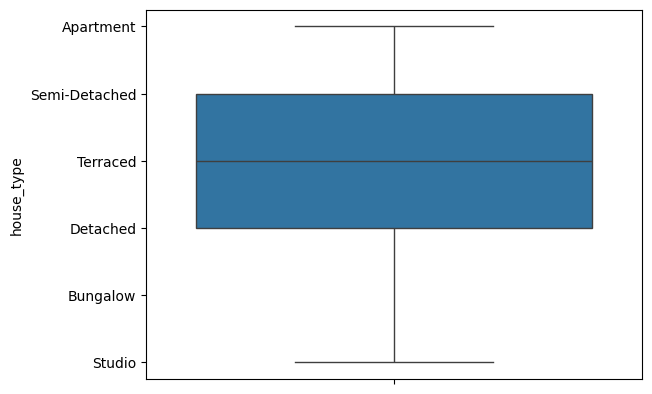

demand_score
Max value 100.0


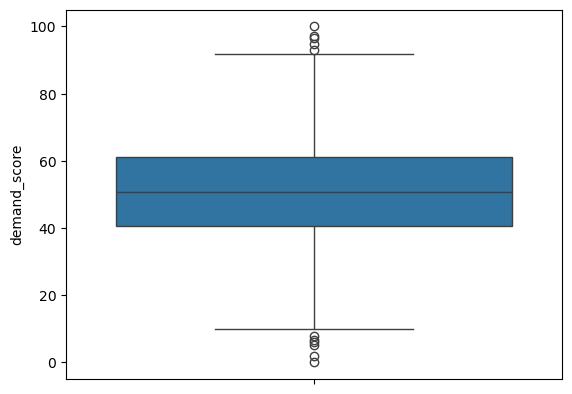

demand_category
Max value Low


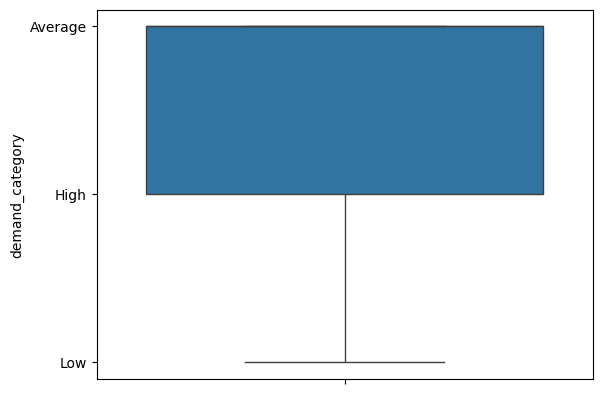

predicted_house_price_eur
Max value 488286.86


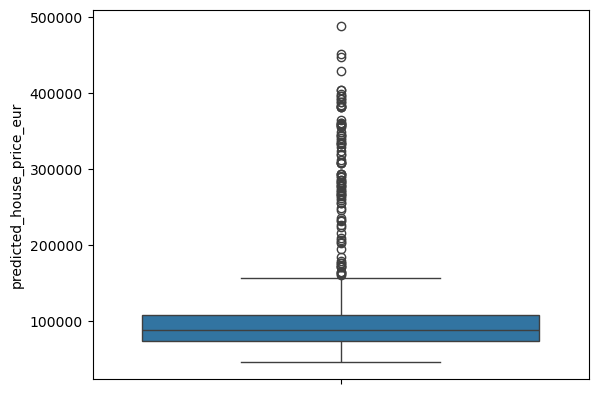

In [22]:
# creating boxplots with features
columns = ['county', 'income', 'land_price', 'transport_score',
       'school_quality_index', 'crime_rate_per_10k', 'green_space_pct',
       'flood_risk_score', 'broadband_score', 'house_type', 'demand_score',
       'demand_category', 'predicted_house_price_eur']

for col in columns:
    print(col)
    data = dfclean[col]
    print("Max value", data.max())
    sns.boxplot(data)
    plt.xticks(rotation=90, fontsize=8)
    plt.show()

<Axes: >

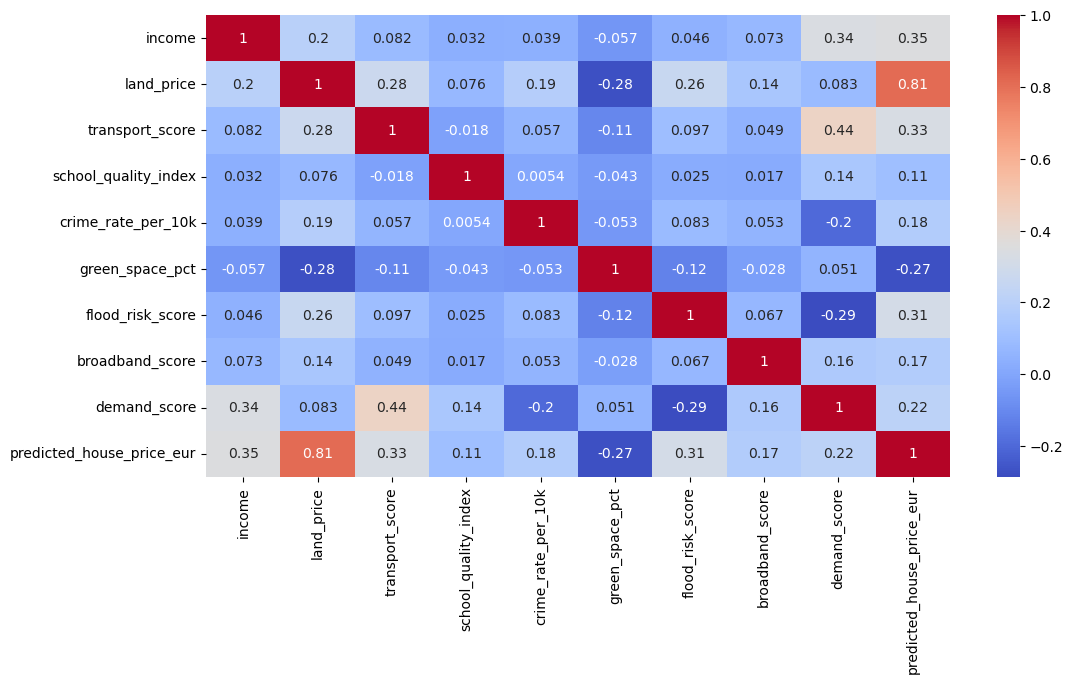

In [23]:
plt.figure(figsize=(12,6))
sns.heatmap(dfclean.select_dtypes(include='number').corr(),annot=True, cmap="coolwarm")

In [24]:
dfclean.select_dtypes(include='number').corr()['predicted_house_price_eur'].sort_values(ascending=False)

predicted_house_price_eur    1.000000
land_price                   0.810517
income                       0.348048
transport_score              0.327180
flood_risk_score             0.307845
demand_score                 0.215429
crime_rate_per_10k           0.175843
broadband_score              0.173299
school_quality_index         0.105038
green_space_pct             -0.270991
Name: predicted_house_price_eur, dtype: float64

From the heat map, we observe that the land price has the strongest correlation with our target variable (predicted house price eur) - 0.81. It means that more expensive land has much higher predicted house price. We also have some features with moderate positive correlations: income 0.35, transport 0.33, flood risk 0.31. weak positive correlations: crime rate 0.18, broadband access 0.17, demand score 0.22, school quality 0.11

In [25]:
# statistics 5
# Linear Regression
X = dfclean [['land_price']] # variable
y = dfclean ['predicted_house_price_eur'] # target

In [26]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [27]:
print('coefficient slope:', model.coef_)
print('intercept:', model.intercept_)

r2 = model.score(X, y)
print('R2 score:', r2)

coefficient slope: [820.58549975]
intercept: 25605.241127275818
R2 score: 0.6569379551231185


county
house_type
demand_category


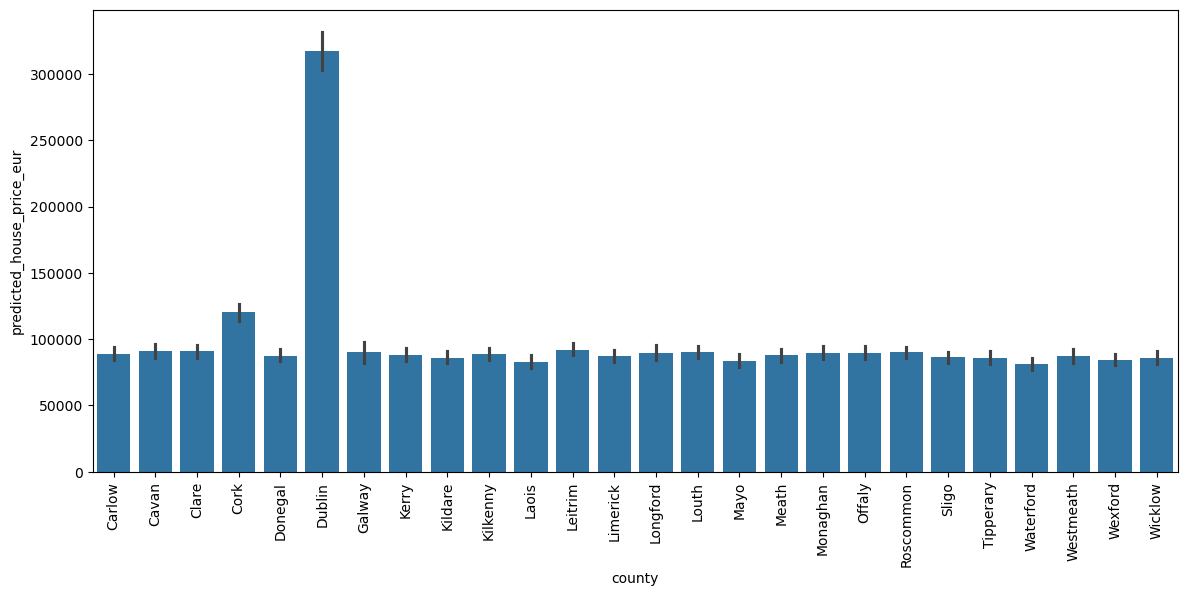

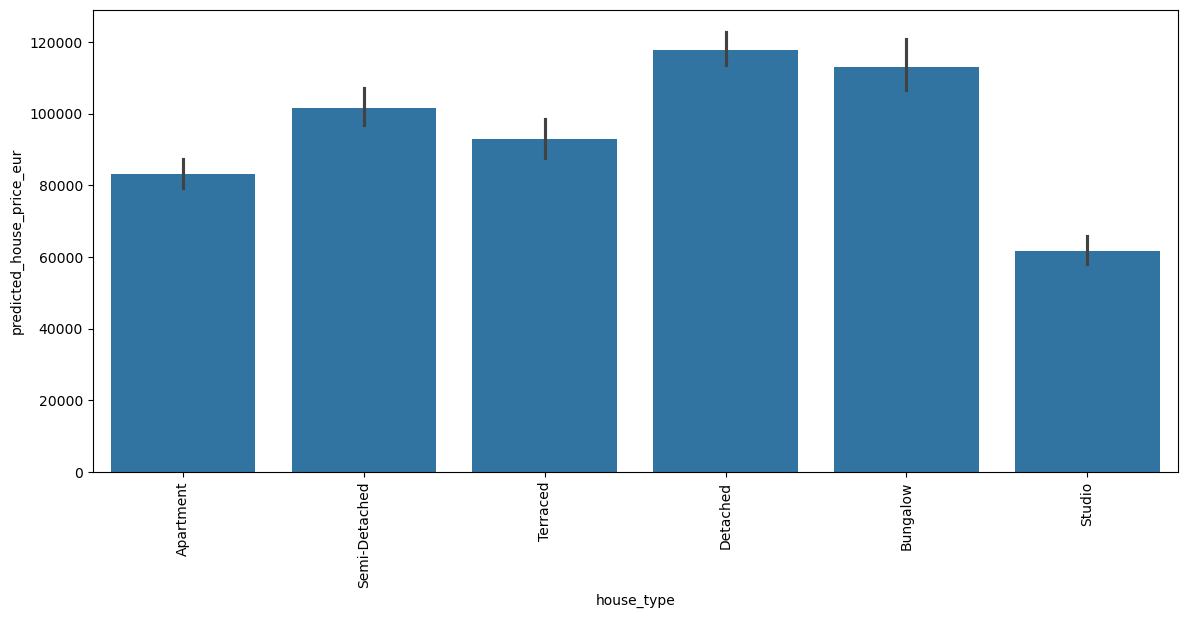

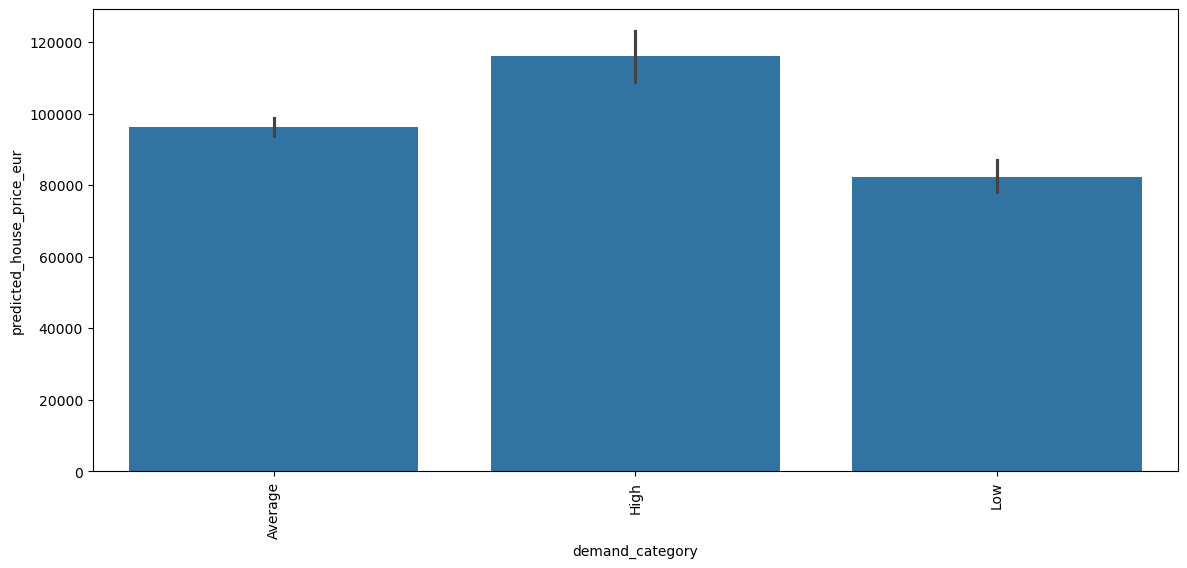

In [28]:
#statistics 1,2
columns = ['county','house_type','demand_category']

for col in columns:
    print(col)
    plt.figure(figsize=(14,6))
    sns.barplot(data=dfclean, x=col, y='predicted_house_price_eur')
    plt.xticks(rotation=90)

county
house_type
demand_category


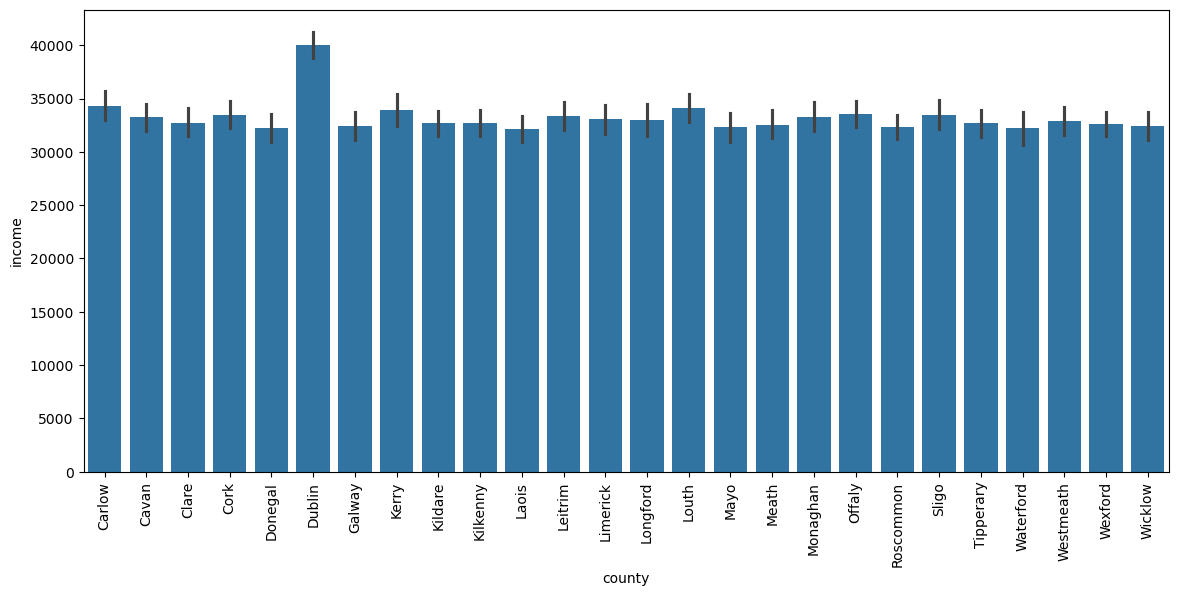

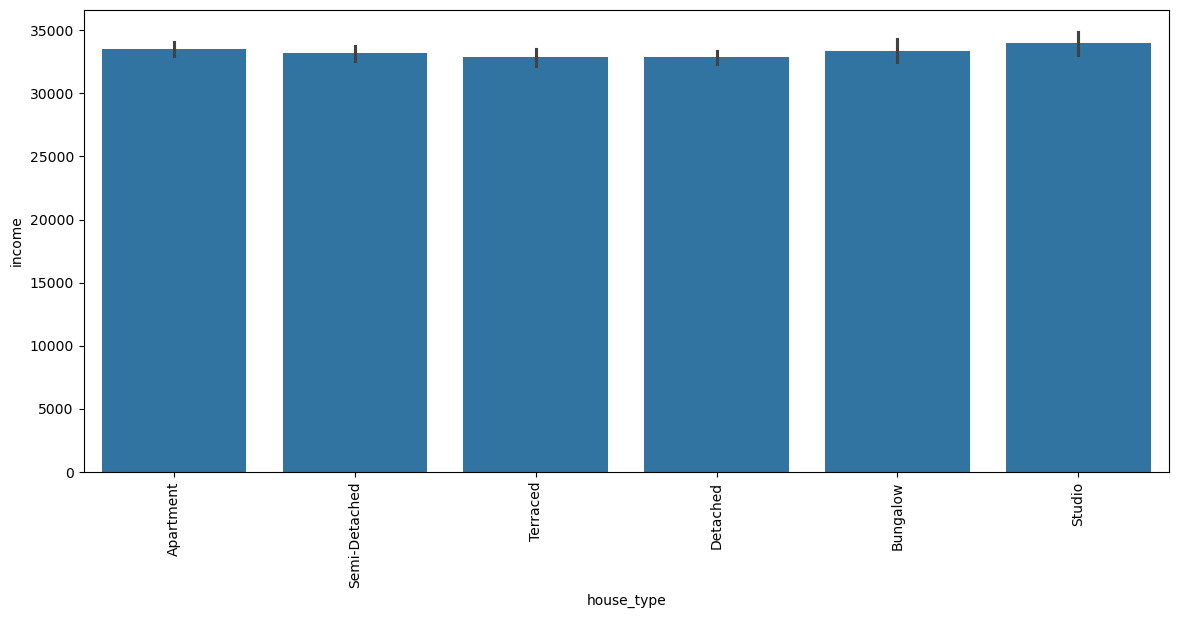

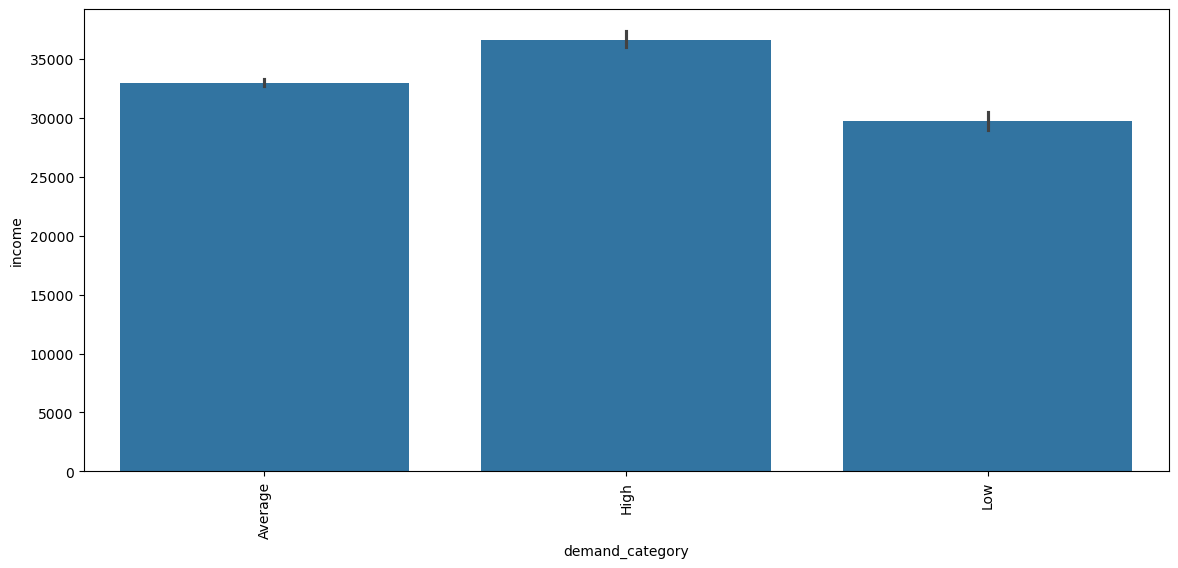

In [29]:
columns = ['county','house_type','demand_category']

for col in columns:
    print(col)
    plt.figure(figsize=(14,6))
    sns.barplot(data=dfclean, x=col, y='income')
    plt.xticks(rotation=90)

We observe that the predictive prices of houses in Dublin County are higher than in any other county, but the income is also higher. Detached and bungalow houses have the highest predicted price and the higer the demand the higher the predictive price.

<Axes: xlabel='house_type', ylabel='count'>

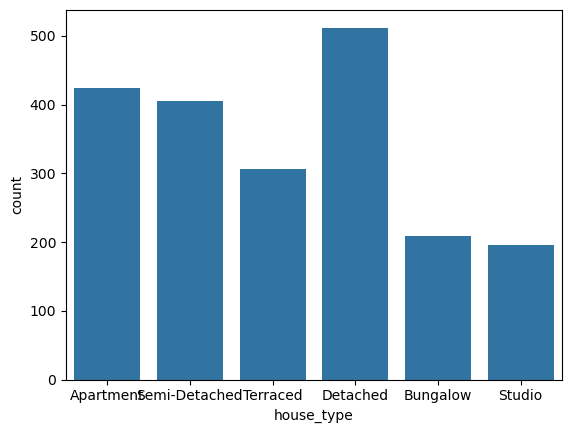

In [30]:
sns.countplot(data=dfclean, x='house_type')

we observe that the biggest amount of house types in ouк dataset are detached houses, after that we have the apartments and semidetached. the lowest amount are the studios.

In [31]:
#probability of each county

prob_county = dfclean['county'].value_counts(normalize=True)
print("probabilities of counties:\n", prob_county.round(2), "\n")

probabilities of counties:
 county
Dublin       0.04
Clare        0.04
Kilkenny     0.04
Galway       0.04
Kildare      0.04
Monaghan     0.04
Louth        0.04
Longford     0.04
Leitrim      0.04
Laois        0.04
Westmeath    0.04
Mayo         0.04
Meath        0.04
Kerry        0.04
Cork         0.04
Roscommon    0.04
Waterford    0.04
Limerick     0.04
Wexford      0.04
Wicklow      0.04
Sligo        0.04
Donegal      0.04
Offaly       0.04
Cavan        0.04
Tipperary    0.04
Carlow       0.04
Name: proportion, dtype: float64 



In [32]:
#central tendencies and variation metrics

numerals = ['income','land_price','transport_score','school_quality_index',
            'crime_rate_per_10k','green_space_pct','flood_risk_score','broadband_score','demand_score']


for i in numerals:
    print(i)
    print(dfclean[i].describe().round(2))
    print('mode - most frequent value')
    print(dfclean[i].mode().round(2))
    print('variance')
    print( dfclean[i].var())
    print('range')
    ra = dfclean[i].max()-dfclean[i].min()
    print(ra)
    print('interquartile range')
    IQR = dfclean[i].quantile(0.75) - dfclean[i].quantile(0.25)
    print(IQR.round(2))
    print('skewness')
    print(dfclean[i].skew().round(2))
    print('=================================================================================')
    

    

income
count     2053.00
mean     33215.98
std       6097.73
min      20000.00
25%      29029.28
50%      33091.36
75%      37364.12
max      55124.80
Name: income, dtype: float64
mode - most frequent value
0    20000.0
Name: income, dtype: float64
variance
37182360.59047154
range
35124.8
interquartile range
8334.84
skewness
0.15
land_price
count    2053.00
mean       88.14
std        51.07
min        10.00
25%        60.33
50%        81.42
75%       103.46
max       390.44
Name: land_price, dtype: float64
mode - most frequent value
0    10.0
Name: land_price, dtype: float64
variance
2608.3393690614953
range
380.44
interquartile range
43.13
skewness
2.62
transport_score
count    2053.00
mean        5.12
std         1.58
min         1.00
25%         4.06
50%         5.10
75%         6.17
max        10.00
Name: transport_score, dtype: float64
mode - most frequent value
0    5.31
Name: transport_score, dtype: float64
variance
2.507840323104399
range
9.0
interquartile range
2.11
skewness
0

In [33]:
numerals = ['income','land_price','transport_score','school_quality_index',
            'crime_rate_per_10k','green_space_pct','flood_risk_score','broadband_score','demand_score']


for i in numerals:
    print(i)
    stat, p_value = stats.shapiro(dfclean[i])
    print("Shapiro-Wilk Test Statistic: ", stat)
    print("p-value:", p_value)
    if p_value >= 0.05:
        print("Sample appears to be normally distributed.")
    else:
        print("Samples does NOT appear to be normally distributed.")
    print('================================================================================')



income
Shapiro-Wilk Test Statistic:  0.995619181859449
p-value: 1.0395253446155867e-05
Samples does NOT appear to be normally distributed.
land_price
Shapiro-Wilk Test Statistic:  0.7553864273311148
p-value: 6.22093427436026e-48
Samples does NOT appear to be normally distributed.
transport_score
Shapiro-Wilk Test Statistic:  0.9978571402701866
p-value: 0.0074365346476714805
Samples does NOT appear to be normally distributed.
school_quality_index
Shapiro-Wilk Test Statistic:  0.9983874597508526
p-value: 0.04349507843704857
Samples does NOT appear to be normally distributed.
crime_rate_per_10k
Shapiro-Wilk Test Statistic:  0.9969635347214343
p-value: 0.000445370133169489
Samples does NOT appear to be normally distributed.
green_space_pct
Shapiro-Wilk Test Statistic:  0.9973299005049006
p-value: 0.0013697339989739302
Samples does NOT appear to be normally distributed.
flood_risk_score
Shapiro-Wilk Test Statistic:  0.8750184469240234
p-value: 9.52191276358745e-38
Samples does NOT appear to

In [34]:
#statistics 3
#choosing samples

high = dfclean[dfclean['demand_category']== 'High']['predicted_house_price_eur']
low = dfclean[dfclean['demand_category']== 'Low']['predicted_house_price_eur']

def confidence_interval(data, confidence=0.95):
    mean = np.mean(data)
    sem = stats.sem(data)
    margin = sem * stats.t.ppf((1+confidence) / 2, len(data)-1)
    return mean - margin, mean + margin, mean


#calculating intervals
interval_high = confidence_interval(high)
interval_low = confidence_interval(low)

print('High demand CI (95%): ', interval_high)
print('Low demand CI (95%): ', interval_low)


High demand CI (95%):  (np.float64(109044.08699696958), np.float64(123233.56318160189), np.float64(116138.82508928573))
Low demand CI (95%):  (np.float64(77500.90243780606), np.float64(86921.31466745709), np.float64(82211.10855263157))


In [35]:
# statistics 5
#performing a Chi-square test to each column against the target variable "predicted_house_price_eur" 
columns = ['county', 'income', 'land_price', 'transport_score',
       'school_quality_index', 'crime_rate_per_10k', 'green_space_pct',
       'flood_risk_score', 'broadband_score', 'house_type', 'demand_score',
       'demand_category']

targetcolumn = 'predicted_house_price_eur'

notimportant = []
important = []

for col in columns:
    
    print(col)
    contingency_table = pd.crosstab(dfclean[col], dfclean[targetcolumn])
    # Run Chi-square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    print("Chi-square Statistic:", chi2)
    print("p-value:", p)

    # Interpret result
    if p < 0.05:
        print("There is a significant relationship between ", col ," and Target.")
        important.append(col)
    else:
        print("No significant relationship between ", col ," and Target.")
        notimportant.append(col)
    
    print('___________________________________________')

print('=================================')    
print('Columns that have significant relationship:')    
print(important)  
print('Columns that have no significant relationship:')    
print(notimportant)    
print('=================================') 

county
Chi-square Statistic: 50976.17404569116
p-value: 0.4048881694345398
No significant relationship between  county  and Target.
___________________________________________
income
Chi-square Statistic: 4121827.9677419085
p-value: 0.006869277625109822
There is a significant relationship between  income  and Target.
___________________________________________
land_price
Chi-square Statistic: 3821586.1785714063
p-value: 0.4978578069508996
No significant relationship between  land_price  and Target.
___________________________________________
transport_score
Chi-square Statistic: 1293013.6166666676
p-value: 0.4617831120782486
No significant relationship between  transport_score  and Target.
___________________________________________
school_quality_index
Chi-square Statistic: 898664.8369597334
p-value: 0.27793582359962044
No significant relationship between  school_quality_index  and Target.
___________________________________________
crime_rate_per_10k
Chi-square Statistic: 3209645.535

In [36]:
dfclean

,county,income,land_price,transport_score,school_quality_index,crime_rate_per_10k,green_space_pct,flood_risk_score,broadband_score,house_type,demand_score,demand_category,predicted_house_price_eur
0,Carlow,35980.28,75.85,5.97,7.02,27.66,28.13,3.18,5.44,Apartment,64.448103,Average,78098.14
1,Carlow,29571.72,52.28,1.08,6.45,38.16,17.81,1.68,5.24,Semi-Detached,36.735072,Average,73503.34
2,Carlow,29733.70,83.33,3.27,5.88,23.99,27.67,0.67,6.99,Terraced,36.575152,Average,75004.94
3,Carlow,49669.88,115.81,5.33,6.38,19.91,17.33,3.15,4.64,Detached,65.913075,Average,152940.93
4,Carlow,28938.47,98.35,6.55,6.43,21.61,27.53,1.66,4.67,Detached,44.816833,Average,107326.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2075,Wicklow,42754.50,72.97,3.38,5.18,36.28,29.57,0.98,5.57,Apartment,46.327921,Average,77780.72
2076,Wicklow,21577.18,125.38,5.32,4.81,32.22,23.32,0.03,3.68,Semi-Detached,25.257086,Low,81847.68
2077,Wicklow,32013.17,81.08,4.49,5.02,37.71,44.30,2.22,7.22,Apartment,45.356938,Average,70058.83
2078,Wicklow,24717.41,74.74,4.74,6.29,36.75,21.92,4.70,6.20,Detached,40.625789,Average,91023.57


In [37]:
# statistics 4
#t test
dublin = dfclean[dfclean['county'] == 'Dublin']['income']
cork = dfclean[dfclean['county'] == 'Cork']['income']

t_stat, p_value = ttest_ind(dublin, cork)

print(f"t_stat: {t_stat}")
print(f"P-value: {p_value}")

t_stat: 7.349467932139135
P-value: 1.0260481850211979e-11


In [38]:
#anova house price across demand categories

low = dfclean[dfclean['demand_category'] == 'Low']['predicted_house_price_eur']
medium = dfclean[dfclean['demand_category'] == 'Average']['predicted_house_price_eur']
high = dfclean[dfclean['demand_category'] == 'High']['predicted_house_price_eur']


f_statistic, p_value = stats.f_oneway(low, medium, high)

print(f"F-statistic: {f_statistic}")
print(f"P-value: {p_value}")


F-statistic: 33.18454887177089
P-value: 6.55406519942302e-15


In [39]:
#anova crime rate across house types

detached = dfclean[dfclean['house_type'] == 'Detached']['crime_rate_per_10k']
semi = dfclean[dfclean['house_type'] == 'Semi-Detached']['crime_rate_per_10k']
apartment = dfclean[dfclean['house_type'] == 'Apartment']['crime_rate_per_10k']



f_statistic, p_value = stats.f_oneway(detached, semi, apartment)

print(f"F-statistic: {f_statistic}")
print(f"P-value: {p_value}")

F-statistic: 1.325014953109086
P-value: 0.26614752273649267


# Encoding

label encoding

In [40]:
dfclean

,county,income,land_price,transport_score,school_quality_index,crime_rate_per_10k,green_space_pct,flood_risk_score,broadband_score,house_type,demand_score,demand_category,predicted_house_price_eur
0,Carlow,35980.28,75.85,5.97,7.02,27.66,28.13,3.18,5.44,Apartment,64.448103,Average,78098.14
1,Carlow,29571.72,52.28,1.08,6.45,38.16,17.81,1.68,5.24,Semi-Detached,36.735072,Average,73503.34
2,Carlow,29733.70,83.33,3.27,5.88,23.99,27.67,0.67,6.99,Terraced,36.575152,Average,75004.94
3,Carlow,49669.88,115.81,5.33,6.38,19.91,17.33,3.15,4.64,Detached,65.913075,Average,152940.93
4,Carlow,28938.47,98.35,6.55,6.43,21.61,27.53,1.66,4.67,Detached,44.816833,Average,107326.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2075,Wicklow,42754.50,72.97,3.38,5.18,36.28,29.57,0.98,5.57,Apartment,46.327921,Average,77780.72
2076,Wicklow,21577.18,125.38,5.32,4.81,32.22,23.32,0.03,3.68,Semi-Detached,25.257086,Low,81847.68
2077,Wicklow,32013.17,81.08,4.49,5.02,37.71,44.30,2.22,7.22,Apartment,45.356938,Average,70058.83
2078,Wicklow,24717.41,74.74,4.74,6.29,36.75,21.92,4.70,6.20,Detached,40.625789,Average,91023.57


In [41]:
# data prep 3
dfclean = dfclean.copy()
dfclean['demand_category'] = le.fit_transform(dfclean['demand_category'])
dfclean['county'] = le.fit_transform(dfclean['county'])
dfclean['house_type'] = le.fit_transform(dfclean['house_type'])


In [42]:
dfclean

,county,income,land_price,transport_score,school_quality_index,crime_rate_per_10k,green_space_pct,flood_risk_score,broadband_score,house_type,demand_score,demand_category,predicted_house_price_eur
0,0,35980.28,75.85,5.97,7.02,27.66,28.13,3.18,5.44,0,64.448103,0,78098.14
1,0,29571.72,52.28,1.08,6.45,38.16,17.81,1.68,5.24,3,36.735072,0,73503.34
2,0,29733.70,83.33,3.27,5.88,23.99,27.67,0.67,6.99,5,36.575152,0,75004.94
3,0,49669.88,115.81,5.33,6.38,19.91,17.33,3.15,4.64,2,65.913075,0,152940.93
4,0,28938.47,98.35,6.55,6.43,21.61,27.53,1.66,4.67,2,44.816833,0,107326.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2075,25,42754.50,72.97,3.38,5.18,36.28,29.57,0.98,5.57,0,46.327921,0,77780.72
2076,25,21577.18,125.38,5.32,4.81,32.22,23.32,0.03,3.68,3,25.257086,2,81847.68
2077,25,32013.17,81.08,4.49,5.02,37.71,44.30,2.22,7.22,0,45.356938,0,70058.83
2078,25,24717.41,74.74,4.74,6.29,36.75,21.92,4.70,6.20,2,40.625789,0,91023.57


In [43]:
# one hot encoding
#dfclean = pd.get_dummies(dfclean, columns=['county','house_type'],drop_first=True)

In [44]:
numerals = ['income','land_price','transport_score','school_quality_index',
            'crime_rate_per_10k','green_space_pct','flood_risk_score','broadband_score','demand_score']

scaler = StandardScaler()
dfclean[numerals] = scaler.fit_transform(dfclean[numerals])

feature engineering

In [45]:
dfclean['environment'] = dfclean['green_space_pct'] - dfclean['flood_risk_score']

In [46]:
dfclean

,county,income,land_price,transport_score,school_quality_index,crime_rate_per_10k,green_space_pct,flood_risk_score,broadband_score,house_type,demand_score,demand_category,predicted_house_price_eur,environment
0,0,0.453443,-0.240691,0.539224,1.470277,-0.302639,-0.148161,0.080307,-0.484208,0,0.906831,0,78098.14,-0.228468
1,0,-0.597788,-0.702310,-2.549397,0.895112,0.717037,-1.377387,-0.567685,-0.649285,3,-0.939306,0,73503.34,-0.809702
2,0,-0.571217,-0.094195,-1.166150,0.319946,-0.659041,-0.202952,-1.003999,0.795141,5,-0.949959,0,75004.94,0.801048
3,0,2.699020,0.541926,0.134988,0.824477,-1.055258,-1.434560,0.067347,-1.144517,2,1.004422,0,152940.93,-1.501907
4,0,-0.701663,0.199971,0.905564,0.874931,-0.890167,-0.219627,-0.576325,-1.119756,2,-0.400930,0,107326.78,0.356697
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2075,25,1.564654,-0.297096,-1.096671,-0.386398,0.534466,0.023359,-0.870081,-0.376908,0,-0.300267,0,77780.72,0.893440
2076,25,-1.909174,0.729354,0.128671,-0.759751,0.140191,-0.721085,-1.280476,-1.936888,3,-1.703925,2,81847.68,0.559391
2077,25,-0.197304,-0.138262,-0.395573,-0.547848,0.673336,1.777865,-0.334408,0.984980,0,-0.364950,0,70058.83,2.112272
2078,25,-1.394066,-0.262431,-0.237668,0.733662,0.580109,-0.887840,0.736939,0.143086,2,-0.680121,0,91023.57,-1.624779


In [47]:
dfclean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2053 entries, 0 to 2079
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   county                     2053 non-null   int64  
 1   income                     2053 non-null   float64
 2   land_price                 2053 non-null   float64
 3   transport_score            2053 non-null   float64
 4   school_quality_index       2053 non-null   float64
 5   crime_rate_per_10k         2053 non-null   float64
 6   green_space_pct            2053 non-null   float64
 7   flood_risk_score           2053 non-null   float64
 8   broadband_score            2053 non-null   float64
 9   house_type                 2053 non-null   int64  
 10  demand_score               2053 non-null   float64
 11  demand_category            2053 non-null   int64  
 12  predicted_house_price_eur  2053 non-null   float64
 13  environment                2053 non-null   float64
dt

In [48]:
#Data prep 4
dfnotarget = dfclean.drop(columns=['predicted_house_price_eur'])


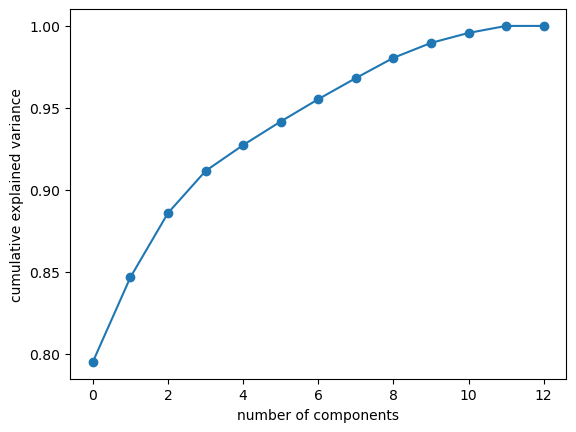

In [49]:
#PCA

pca=PCA().fit(dfnotarget)
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('number of components')
plt.ylabel ('cumulative explained variance');
plt.show()

In [50]:
pca=PCA(11)
projected=pca.fit_transform(dfnotarget)

In [51]:
 dfpca = pd.DataFrame(projected, columns=['C1','C2','C3','C4','C5','C6','C7','C8','C9','C10','C11'], index=dfnotarget.index)

In [52]:
dfpca['predicted_house_price_eur'] = dfclean['predicted_house_price_eur']

In [53]:
dfpca

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,predicted_house_price_eur
0,-12.516479,0.082018,-2.310704,0.999124,-1.178979,0.827774,-0.779402,-0.176640,0.499695,-0.635846,-0.244622,78098.14
1,-12.522908,-0.286417,0.547102,-2.360426,-0.637076,1.603449,-0.616288,0.548022,-1.779019,-0.278880,-0.556892,73503.34
2,-12.510061,1.447715,2.526349,-1.194811,-0.276856,0.764088,0.790398,-0.320846,-1.056014,0.672016,-0.277732,75004.94
3,-12.585493,-1.433016,-0.228061,1.735192,-1.984896,0.391282,-0.769201,2.203726,-0.112459,-0.023304,-0.219404,152940.93
4,-12.500244,0.699666,-0.321123,-0.146747,-1.220098,-0.089053,-1.326368,-0.920618,0.257812,0.451852,-0.224887,107326.78
...,...,...,...,...,...,...,...,...,...,...,...,...
2075,12.495280,0.685414,-2.351118,0.109005,0.427464,0.342339,-0.163071,1.916151,-0.865467,0.052069,-0.273420,77780.72
2076,12.493021,0.095088,0.758900,-1.957037,0.164247,-1.208323,-2.066070,-0.757548,-0.879679,1.539529,1.573015,81847.68
2077,12.529720,1.981341,-2.438321,-0.073775,1.697569,0.126799,0.868653,-0.186062,0.331015,0.285289,-0.351950,70058.83
2078,12.438881,-2.212350,-0.164449,-0.976764,0.011640,0.788683,-0.251686,-1.159433,-0.378601,-0.369190,-0.496056,91023.57


In [54]:
#divided target value into 3 categories

In [55]:
y_class = pd.qcut(dfclean['predicted_house_price_eur'], q=3, labels=['Low', 'Medium', 'High'] )

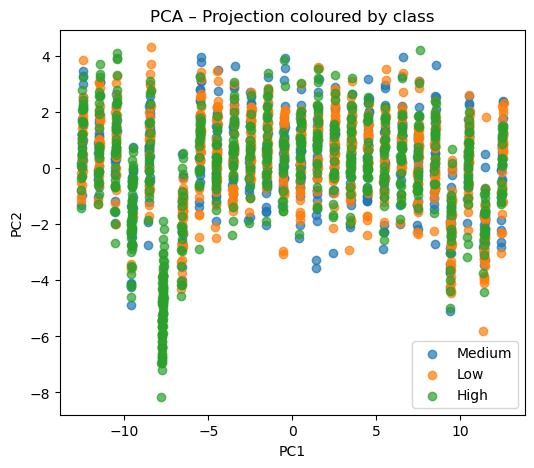

In [56]:
plt.figure(figsize=(6,5))
for label in y_class.unique():
    plt.scatter(
        projected[y_class == label, 0],
        projected[y_class == label, 1],
        label=label,
        alpha=0.7
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA – Projection coloured by class')
plt.legend()
plt.show()

In [57]:
lda = LinearDiscriminantAnalysis(n_components=2)
Xlda = lda.fit_transform(projected, y_class)

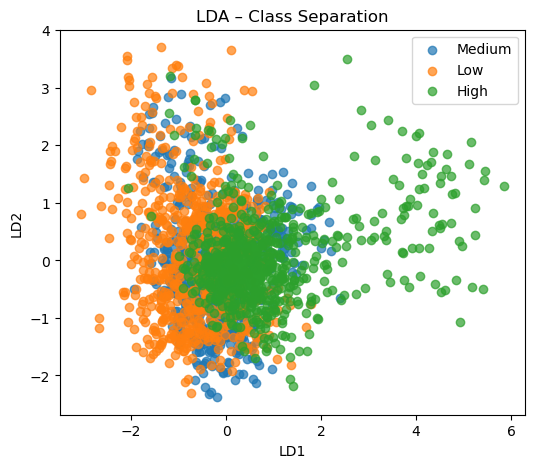

In [58]:
plt.figure(figsize=(6,5))
for label in y_class.unique():
    plt.scatter(
        Xlda[y_class == label, 0],
        Xlda[y_class == label, 1],
        label=label,
        alpha=0.7
    )

plt.xlabel('LD1')
plt.ylabel('LD2')
plt.title('LDA – Class Separation')
plt.legend()
plt.show()

In [59]:
dfclean

,county,income,land_price,transport_score,school_quality_index,crime_rate_per_10k,green_space_pct,flood_risk_score,broadband_score,house_type,demand_score,demand_category,predicted_house_price_eur,environment
0,0,0.453443,-0.240691,0.539224,1.470277,-0.302639,-0.148161,0.080307,-0.484208,0,0.906831,0,78098.14,-0.228468
1,0,-0.597788,-0.702310,-2.549397,0.895112,0.717037,-1.377387,-0.567685,-0.649285,3,-0.939306,0,73503.34,-0.809702
2,0,-0.571217,-0.094195,-1.166150,0.319946,-0.659041,-0.202952,-1.003999,0.795141,5,-0.949959,0,75004.94,0.801048
3,0,2.699020,0.541926,0.134988,0.824477,-1.055258,-1.434560,0.067347,-1.144517,2,1.004422,0,152940.93,-1.501907
4,0,-0.701663,0.199971,0.905564,0.874931,-0.890167,-0.219627,-0.576325,-1.119756,2,-0.400930,0,107326.78,0.356697
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2075,25,1.564654,-0.297096,-1.096671,-0.386398,0.534466,0.023359,-0.870081,-0.376908,0,-0.300267,0,77780.72,0.893440
2076,25,-1.909174,0.729354,0.128671,-0.759751,0.140191,-0.721085,-1.280476,-1.936888,3,-1.703925,2,81847.68,0.559391
2077,25,-0.197304,-0.138262,-0.395573,-0.547848,0.673336,1.777865,-0.334408,0.984980,0,-0.364950,0,70058.83,2.112272
2078,25,-1.394066,-0.262431,-0.237668,0.733662,0.580109,-0.887840,0.736939,0.143086,2,-0.680121,0,91023.57,-1.624779


In [60]:
# machine 1
features = ['land_price', 'income', 'transport_score', 'flood_risk_score',
            'demand_score', 'crime_rate_per_10k', 'broadband_score',
            'school_quality_index', 'green_space_pct']
X = dfclean[features]
y = pd.qcut(dfclean['predicted_house_price_eur'], q=3, labels=['Low', 'Medium', 'High'])

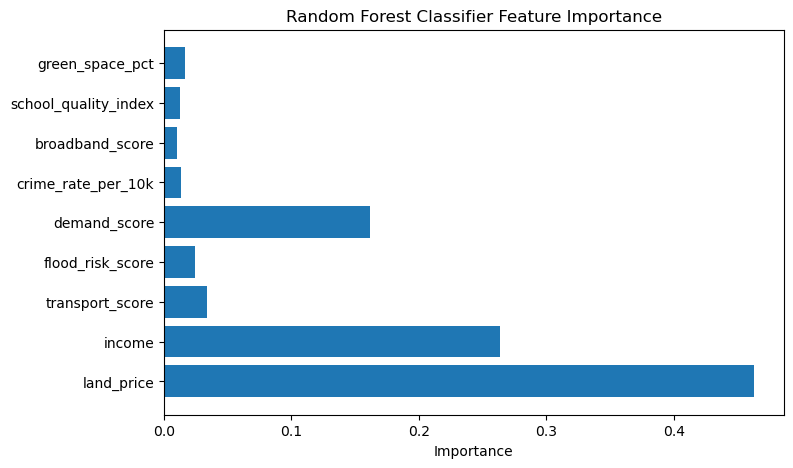

Best Hyperparameters: {'max_depth': 4, 'max_features': 5, 'n_estimators': 200}


In [61]:
#machine 2
rf = RandomForestClassifier(random_state=1)

# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 8, 10, None],
    'max_features': [ 5, 10, 20]
}

# GridSearchCV with 5-fold CV using accuracy
grid_search_rf = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy')
grid_search_rf.fit(X, y)

# Feature importance
importances = grid_search_rf.best_estimator_.feature_importances_
plt.figure(figsize=(8,5))
plt.barh(features, importances)
plt.title("Random Forest Classifier Feature Importance")
plt.xlabel("Importance")
plt.show()

print("Best Hyperparameters:", grid_search_rf.best_params_)

In [62]:
#machine 3
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=1)

# Train Random Forest Classifier with best hyperparameters
rf_best = RandomForestClassifier(random_state=1, **grid_search_rf.best_params_)
rf_best.fit(X_train, y_train)

# Predict
y_pred = rf_best.predict(X_test)

# Evaluate
accuracy1 = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy1)
print("Classification Report:", classification_report(y_test, y_pred))
print("Confusion Matrix:", confusion_matrix(y_test, y_pred))

Test Accuracy: 0.5036496350364964
Classification Report:               precision    recall  f1-score   support

        High       0.56      0.62      0.59       139
         Low       0.59      0.52      0.55       132
      Medium       0.38      0.38      0.38       140

    accuracy                           0.50       411
   macro avg       0.51      0.50      0.50       411
weighted avg       0.51      0.50      0.50       411

Confusion Matrix: [[86  6 47]
 [23 68 41]
 [45 42 53]]


In [63]:
# 10-fold CV
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
cv_scores2 = cross_val_score(rf_best, X, y_class, cv=kfold, scoring='accuracy')

print("10-Fold CV Accuracy: ",(cv_scores2.mean()))

10-Fold CV Accuracy:  0.5153421738100876


In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.30, random_state=1)

# Train Random Forest Classifier with best hyperparameters
rf_best2 = RandomForestClassifier(random_state=1, **grid_search_rf.best_params_)
rf_best2.fit(X_train, y_train)

# Predict
y_pred = rf_best2.predict(X_test)

# Evaluate
accuracy3 = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy3)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Test Accuracy: 0.5064935064935064

Classification Report:
               precision    recall  f1-score   support

        High       0.54      0.68      0.60       203
         Low       0.59      0.56      0.58       200
      Medium       0.36      0.29      0.32       213

    accuracy                           0.51       616
   macro avg       0.50      0.51      0.50       616
weighted avg       0.50      0.51      0.50       616


Confusion Matrix:
 [[138  12  53]
 [ 32 112  56]
 [ 86  65  62]]


In [65]:
# 20-fold CV
kfold = KFold(n_splits=20, shuffle=True, random_state=1)
cv_scores4 = cross_val_score(rf_best2, X, y_class, cv=kfold, scoring='accuracy')

print("20-Fold CV Accuracy: ", (cv_scores4.mean()))

20-Fold CV Accuracy:  0.5148296211688559


In [66]:
dfpca = dfpca.values

In [67]:
X = dfpca[:, :-1]
y = dfpca[:, -1]

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=1)

# Train Random Forest Classifier with best hyperparameters
rf_best = RandomForestClassifier(random_state=1, **grid_search_rf.best_params_)
rf_best.fit(X_train, y_train)

# Predict
y_pred = rf_best.predict(X_test)

# Evaluate
accuracy5 = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy5)
print("Classification Report:", classification_report(y_test, y_pred))
print("Confusion Matrix:", confusion_matrix(y_test, y_pred))

Test Accuracy: 0.7274939172749392
Classification Report:               precision    recall  f1-score   support

        High       0.79      0.85      0.82       139
         Low       0.72      0.80      0.76       132
      Medium       0.65      0.54      0.59       140

    accuracy                           0.73       411
   macro avg       0.72      0.73      0.72       411
weighted avg       0.72      0.73      0.72       411

Confusion Matrix: [[118   4  17]
 [  3 106  23]
 [ 28  37  75]]


In [69]:
# 10-fold CV
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
cv_scores6 = cross_val_score(rf_best, X, y_class, cv=kfold, scoring='accuracy')

print("10-Fold CV Accuracy: ",(cv_scores6.mean()))

10-Fold CV Accuracy:  0.7325953113900071


In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.3, random_state=1)

# Train Random Forest Classifier with best hyperparameters
rf_best = RandomForestClassifier(random_state=1, **grid_search_rf.best_params_)
rf_best.fit(X_train, y_train)

# Predict
y_pred = rf_best.predict(X_test)

# Evaluate
accuracy7 = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy7)
print("Classification Report:", classification_report(y_test, y_pred))
print("Confusion Matrix:", confusion_matrix(y_test, y_pred))

Test Accuracy: 0.724025974025974
Classification Report:               precision    recall  f1-score   support

        High       0.79      0.86      0.82       203
         Low       0.71      0.79      0.75       200
      Medium       0.66      0.54      0.59       213

    accuracy                           0.72       616
   macro avg       0.72      0.73      0.72       616
weighted avg       0.72      0.72      0.72       616

Confusion Matrix: [[174   7  22]
 [  4 158  38]
 [ 41  58 114]]


In [71]:
# 30-fold CV
kfold = KFold(n_splits=30, shuffle=True, random_state=1)
cv_scores8 = cross_val_score(rf_best, X, y_class, cv=kfold, scoring='accuracy')

print("30-Fold CV Accuracy: ",(cv_scores8.mean()))

30-Fold CV Accuracy:  0.7385265700483092


In [72]:
#divided target value into 2 categories

In [73]:
y_class = pd.qcut(dfclean['predicted_house_price_eur'], q=2, labels=['Low', 'High'] )

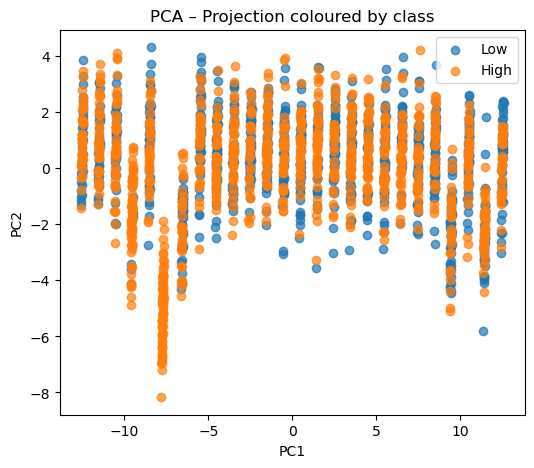

In [74]:
plt.figure(figsize=(6,5))
for label in y_class.unique():
    plt.scatter(
        projected[y_class == label, 0],
        projected[y_class == label, 1],
        label=label,
        alpha=0.7
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA – Projection coloured by class')
plt.legend()
plt.show()

In [75]:
lda = LinearDiscriminantAnalysis(n_components=1)
Xlda = lda.fit_transform(projected, y_class)

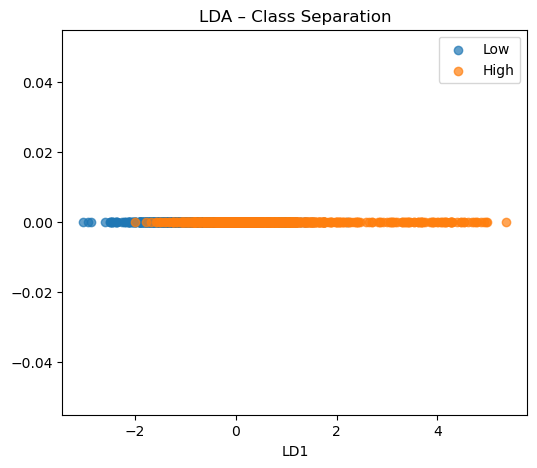

In [76]:
plt.figure(figsize=(6,5))
for label in y_class.unique():
    plt.scatter(
        Xlda[y_class == label, 0],
        [0]*sum(y_class == label),
        label=label,
        alpha=0.7
    )

plt.xlabel('LD1')
plt.title('LDA – Class Separation')
plt.legend()
plt.show()

In [77]:
# machine 1
features = ['land_price', 'income', 'transport_score', 'flood_risk_score',
            'demand_score', 'crime_rate_per_10k', 'broadband_score',
            'school_quality_index', 'green_space_pct']
X = dfclean[features]
y = pd.qcut(dfclean['predicted_house_price_eur'], q=2, labels=['Low', 'High'])

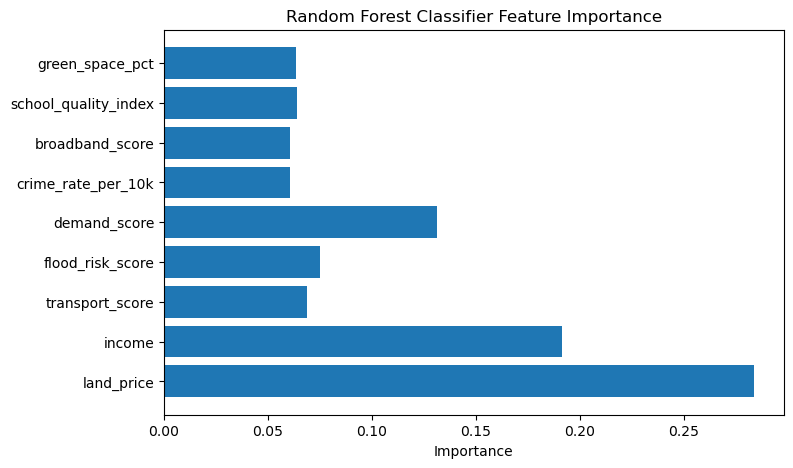

Best Hyperparameters: {'max_depth': 8, 'max_features': 5, 'n_estimators': 100}


In [78]:
#machine 2
rf = RandomForestClassifier(random_state=1)

# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 8, 10, None],
    'max_features': [ 5, 10, 20]
}

# GridSearchCV with 5-fold CV using accuracy
grid_search_rf = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy')
grid_search_rf.fit(X, y)

# Feature importance
importances = grid_search_rf.best_estimator_.feature_importances_
plt.figure(figsize=(8,5))
plt.barh(features, importances)
plt.title("Random Forest Classifier Feature Importance")
plt.xlabel("Importance")
plt.show()

print("Best Hyperparameters:", grid_search_rf.best_params_)

In [79]:
#machine 3
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=1)

# Train Random Forest Classifier with best hyperparameters
rf_best = RandomForestClassifier(random_state=1, **grid_search_rf.best_params_)
rf_best.fit(X_train, y_train)

# Predict
y_pred = rf_best.predict(X_test)

# Evaluate
accuracy10 = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy10)
print("Classification Report:", classification_report(y_test, y_pred))
print("Confusion Matrix:", confusion_matrix(y_test, y_pred))

Test Accuracy: 0.683698296836983
Classification Report:               precision    recall  f1-score   support

        High       0.67      0.71      0.69       202
         Low       0.70      0.66      0.68       209

    accuracy                           0.68       411
   macro avg       0.68      0.68      0.68       411
weighted avg       0.68      0.68      0.68       411

Confusion Matrix: [[143  59]
 [ 71 138]]


In [80]:
X = dfpca[:, :-1]
y = dfpca[:, -1]

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=1)

# Train Random Forest Classifier with best hyperparameters
rf_best = RandomForestClassifier(random_state=1, **grid_search_rf.best_params_)
rf_best.fit(X_train, y_train)

# Predict
y_pred = rf_best.predict(X_test)

# Evaluate
accuracy20 = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy20)
print("Classification Report:", classification_report(y_test, y_pred))
print("Confusion Matrix:", confusion_matrix(y_test, y_pred))

Test Accuracy: 0.8929440389294404
Classification Report:               precision    recall  f1-score   support

        High       0.89      0.90      0.89       202
         Low       0.90      0.89      0.89       209

    accuracy                           0.89       411
   macro avg       0.89      0.89      0.89       411
weighted avg       0.89      0.89      0.89       411

Confusion Matrix: [[181  21]
 [ 23 186]]


In [82]:
# 30-fold CV
kfold = KFold(n_splits=30, shuffle=True, random_state=1)
cv_scores30 = cross_val_score(rf_best, X, y_class, cv=kfold, scoring='accuracy')

print("30-Fold CV Accuracy: ",(cv_scores30.mean()))

30-Fold CV Accuracy:  0.8923913043478262


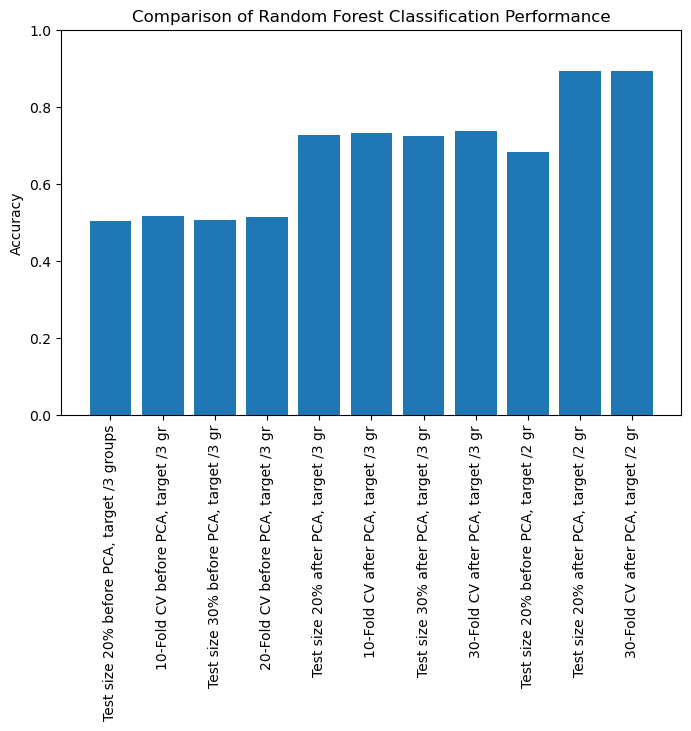

In [85]:
#machine 4
results = {
    'Model / Evaluation': [
        'Test size 20% before PCA, target /3 groups',
        '10-Fold CV before PCA, target /3 gr',
        'Test size 30% before PCA, target /3 gr',
        '20-Fold CV before PCA, target /3 gr',
        'Test size 20% after PCA, target /3 gr',
        '10-Fold CV after PCA, target /3 gr',
        'Test size 30% after PCA, target /3 gr',
        '30-Fold CV after PCA, target /3 gr',
        'Test size 20% before PCA, target /2 gr',
        'Test size 20% after PCA, target /2 gr',
        '30-Fold CV after PCA, target /2 gr'  
    ],
    'Accuracy': [accuracy1, cv_scores2.mean(), accuracy3, cv_scores4.mean(), accuracy5, cv_scores6.mean(), accuracy7, cv_scores8.mean(), accuracy10, accuracy20, cv_scores30.mean()]
}

df_results = pd.DataFrame(results)

# Plot
plt.figure(figsize=(8,5))
plt.bar(df_results['Model / Evaluation'], df_results['Accuracy'])
plt.ylim(0,1)
plt.ylabel('Accuracy')
plt.title('Comparison of Random Forest Classification Performance')
plt.xticks(rotation=90)
plt.show()

In [86]:
df_results

,Model / Evaluation,Accuracy
0,"Test size 20% before PCA, target /3 groups",0.503650
1,"10-Fold CV before PCA, target /3 gr",0.515342
2,"Test size 30% before PCA, target /3 gr",0.506494
3,"20-Fold CV before PCA, target /3 gr",0.514830
4,"Test size 20% after PCA, target /3 gr",0.727494
5,"10-Fold CV after PCA, target /3 gr",0.732595
6,"Test size 30% after PCA, target /3 gr",0.724026
7,"30-Fold CV after PCA, target /3 gr",0.738527
8,"Test size 20% before PCA, target /2 gr",0.683698
9,"Test size 20% after PCA, target /2 gr",0.892944
